In [216]:
# to remove warning 
# setting the environment variable
%env OMP_NUM_THREADS=9

env: OMP_NUM_THREADS=9


In [217]:
# Load libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [218]:
# Open the file

readmits_df = pd.read_csv("C:/Users/rmtol/OneDrive/Desktop/Bellevue/DSC 630/diabetic_data.csv")

In [219]:
# display column names for easy reference

print(readmits_df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [220]:
# Show first rows of data

print(readmits_df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [221]:
# Encounter ID and patient number columns

readmits_df = readmits_df.drop(columns=['encounter_id', 'patient_nbr', 'weight','payer_code'])

In [222]:
# show the number of columns after Encounter ID and patient number columns

num_columns_new = len(readmits_df.columns)
print("Number of columns after removing ID and Subject ID:", num_columns_new)

Number of columns after removing ID and Subject ID: 46


In [223]:
import seaborn as sns

In [263]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

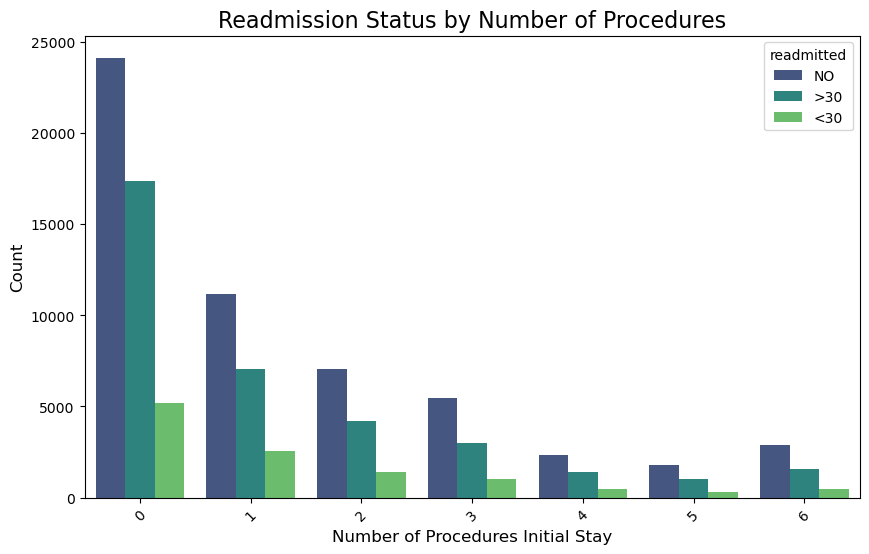

In [251]:
# Readmission Status by Number of procedures (other than lab tests) performed during the encounter

plt.figure(figsize=(10, 6))
sns.countplot(x='num_procedures', hue='readmitted', data=readmits_df, palette='viridis')

# Set the title and axis labels
plt.title('Readmission Status by Number of Procedures', fontsize=16)
plt.xlabel('Number of Procedures Initial Stay', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Rotate X-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

In [265]:
# Inspect unique values in the 'readmitted' column
print(readmits_df['readmitted'].unique())


['NO' '>30' '<30']


In [267]:
# separate and encode target variable
y = readmits_df['readmitted'].map({'NO':0, '<30':1, '>30':2})
X = readmits_df.drop('readmitted', axis=1)

In [269]:
# Inspect unique values in the 'readmitted' column
print(y.unique())

[0 2 1]


In [271]:
# find categorial columns
categorical_columns = X.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed'],
      dtype='object')


In [273]:
X = pd.get_dummies(X, columns=categorical_columns)

In [275]:
# Check for null values
print(readmits_df.isnull().sum())


race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

In [277]:
print(X.shape)
print(y.shape)

(101766, 2442)
(101766,)


In [279]:
print(y.isnull().sum())

0


In [283]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [285]:
# Initialize and fit the model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

C:\Users\rmtol\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [287]:
# Make predictions
y_pred = model.predict(X_test)

In [289]:
# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.85      0.71     10952
           1       0.39      0.02      0.04      2285
           2       0.50      0.33      0.40      7117

    accuracy                           0.58     20354
   macro avg       0.50      0.40      0.38     20354
weighted avg       0.54      0.58      0.52     20354



In [291]:
from sklearn.ensemble import RandomForestClassifier

In [293]:
# Initialize and fit the Random Forest model
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [295]:
y_pred_rf = model_rf.predict(X_test)

In [297]:
# Evaluate the model
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.60      0.88      0.71     10952
           1       0.50      0.01      0.02      2285
           2       0.51      0.31      0.38      7117

    accuracy                           0.58     20354
   macro avg       0.54      0.40      0.37     20354
weighted avg       0.56      0.58      0.52     20354

